In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline
import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D,Input

In [ ]:
import os
import zipfile
from tqdm import tqdm

# Path to the ZIP file
ZIP_PATH = 'age-n-gender.zip'
EXTRACT_DIR = 'age-n-gender'

# Extract the ZIP file
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

In [ ]:
image_paths = []
age_labels = []
gender_labels = []

for filename in tqdm(os.listdir(EXTRACT_DIR)):
    image_path = os.path.join(EXTRACT_DIR, filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

100%|██████████| 23708/23708 [00:00<00:00, 252398.15it/s]


In [ ]:
# convert to dataframe
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_labels
df.head()

,image,age,gender
0,age-n-gender/9_0_0_20170110220658769.jpg.chip.jpg,9,0
1,age-n-gender/26_1_2_20170116180307033.jpg.chip...,26,1
2,age-n-gender/14_0_0_20170103200611317.jpg.chip...,14,0
3,age-n-gender/75_1_1_20170112211657821.jpg.chip...,75,1
4,age-n-gender/29_1_1_20170116000522670.jpg.chip...,29,1


In [ ]:
# map labels for gender
gender_dict = {0:'Male', 1:'Female'}

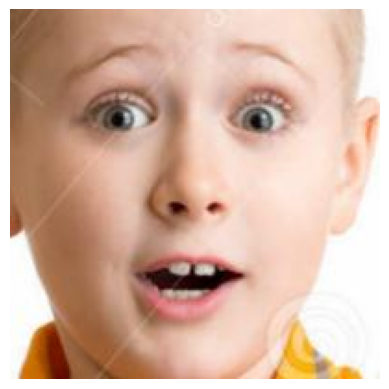

In [ ]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

<Axes: xlabel='age', ylabel='Density'>

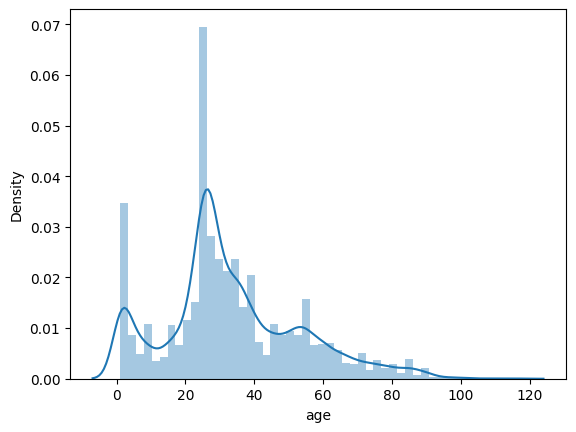

In [ ]:
sns.distplot(df['age'])

<Axes: ylabel='count'>

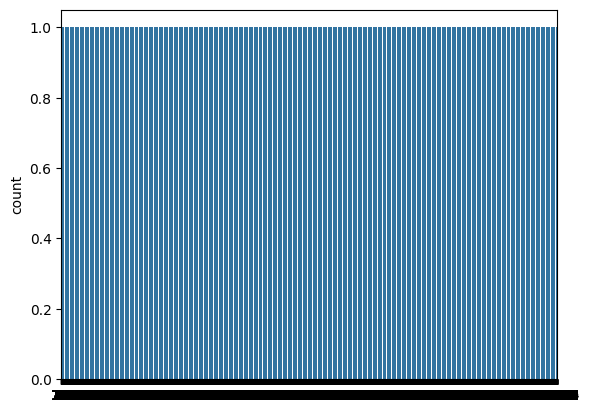

In [ ]:
sns.countplot(df['gender'])

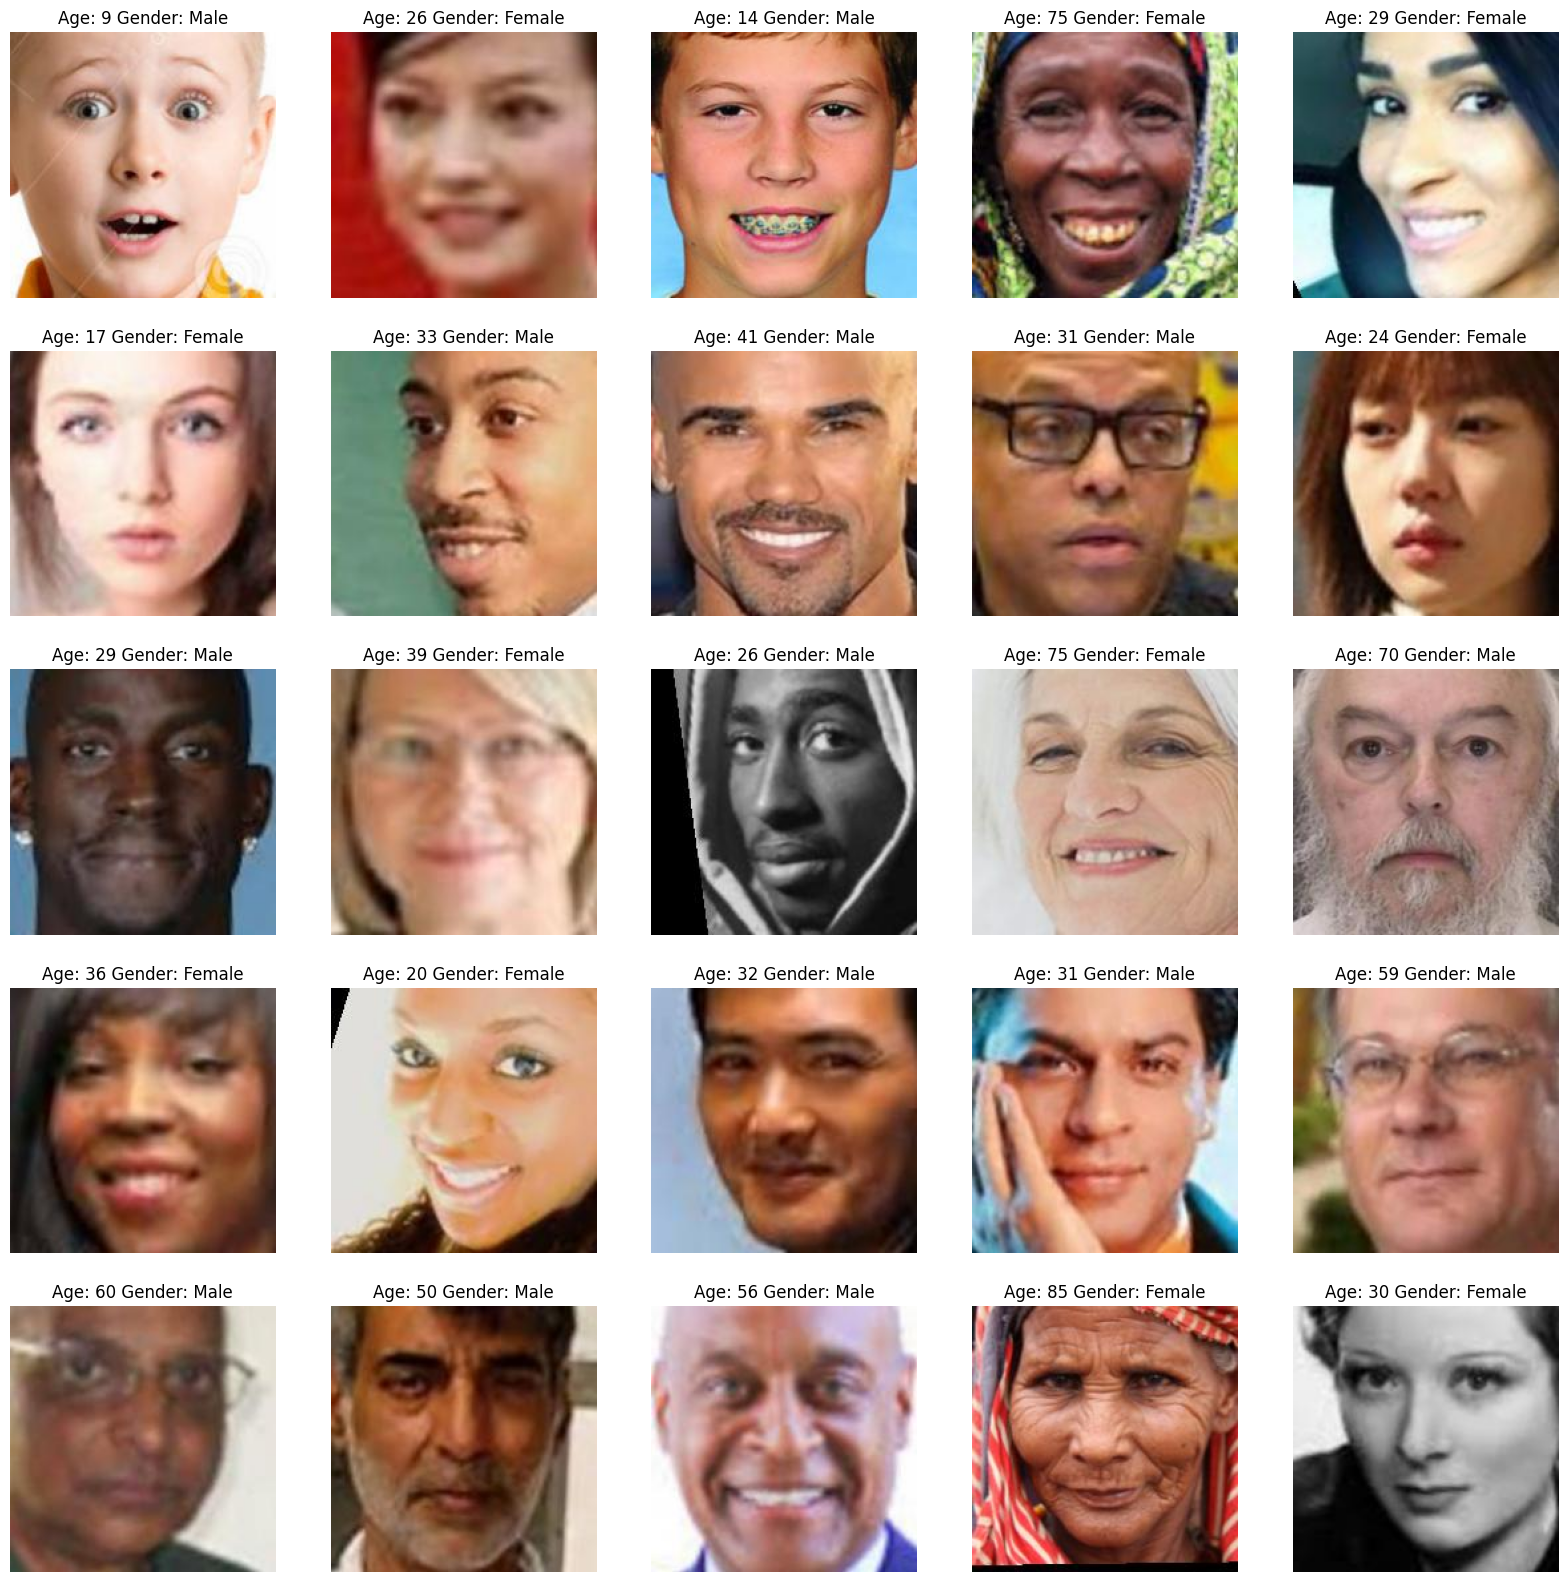

In [ ]:
# to display grid of images
plt.figure(figsize=(20, 20))
files = df.iloc[0:25]

for index, file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age} Gender: {gender_dict[gender]}")
    plt.axis('off')

In [ ]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')
        img = img.resize((128, 128), Image.LANCZOS)  # Replaced Image.ANTIALIAS with Image.LANCZOS
        img = np.array(img)  # Convert image to NumPy array
        features.append(img)  # Append to the features list

    features = np.array(features)
    # Ignore this step if using RGB
    features = features.reshape(len(features), 128, 128, 1)
    return features

In [ ]:
X = extract_features(df['image'])
X.shape

100%|██████████| 23708/23708 [00:31<00:00, 758.48it/s]


(23708, 128, 128, 1)

In [ ]:
# normalize the images
X = X/255.0

In [ ]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [ ]:
input_shape = (128, 128, 1)

In [ ]:
inputs = Input((input_shape))
# convolutional layers
conv_1 = Conv2D(32, kernel_size=(3, 3), activation='relu') (inputs)
maxp_1 = MaxPooling2D(pool_size=(2, 2)) (conv_1)
conv_2 = Conv2D(64, kernel_size=(3, 3), activation='relu') (maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2, 2)) (conv_2)
conv_3 = Conv2D(128, kernel_size=(3, 3), activation='relu') (maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2, 2)) (conv_3)
conv_4 = Conv2D(256, kernel_size=(3, 3), activation='relu') (maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2, 2)) (conv_4)

flatten = Flatten() (maxp_4)

# fully connected layers
dense_1 = Dense(256, activation='relu') (flatten)
dense_2 = Dense(256, activation='relu') (flatten)

dropout_1 = Dropout(0.3) (dense_1)
dropout_2 = Dropout(0.3) (dense_2)

output_1 = Dense(1, activation='sigmoid', name='gender_out') (dropout_1)
output_2 = Dense(1, activation='relu', name='age_out') (dropout_2)

model = Model(inputs=[inputs], outputs=[output_1, output_2])

model.compile(loss=['binary_crossentropy', 'mae'], optimizer='adam', metrics=['accuracy', 'mae'])

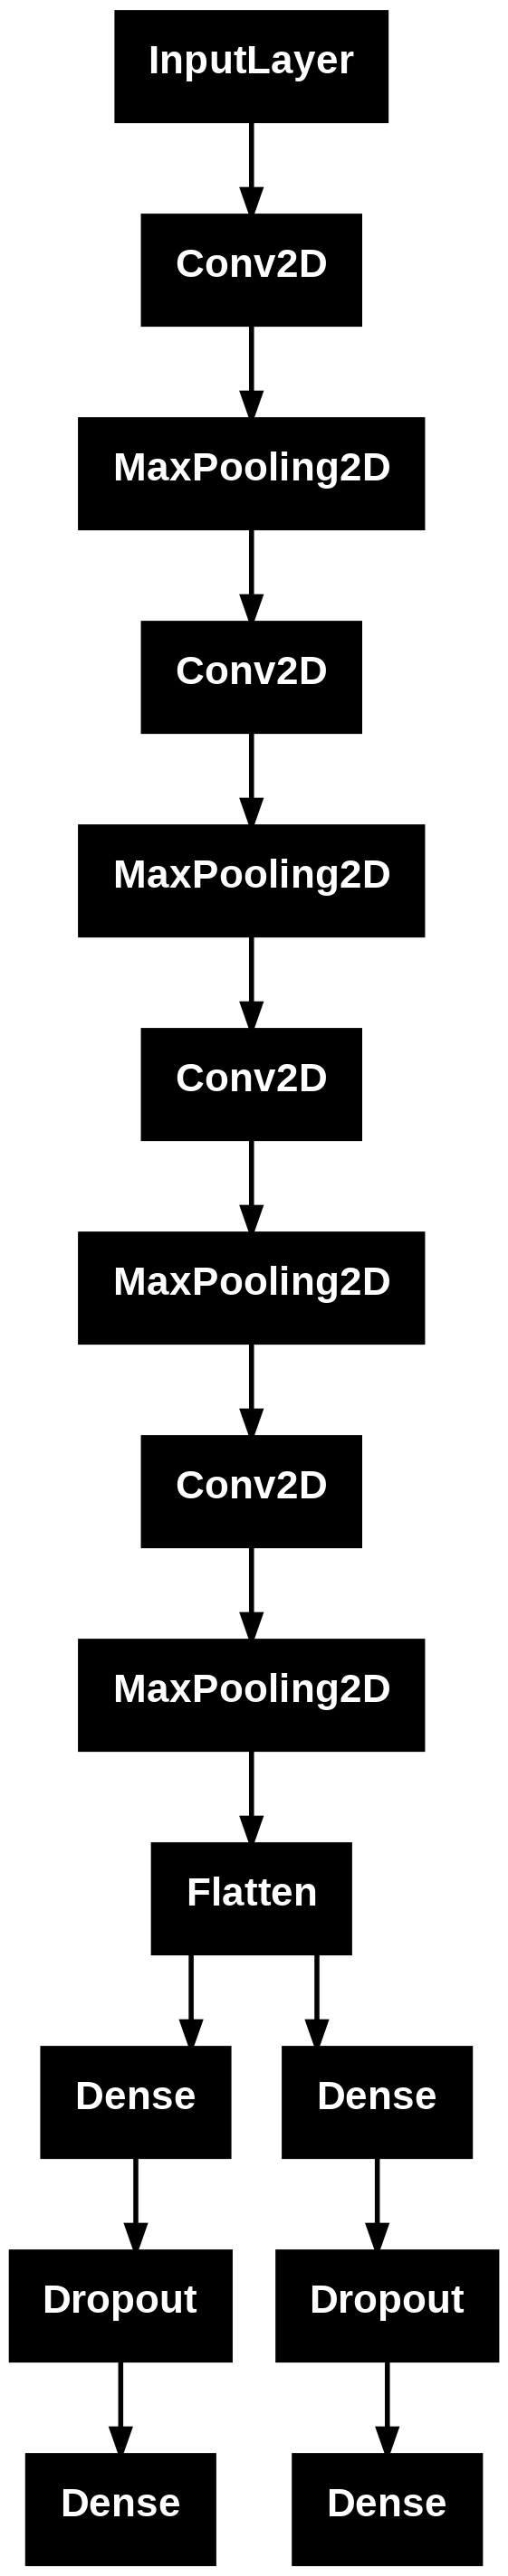

In [ ]:
 # plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [ ]:
# train model
history = model.fit(x=X, y=[y_gender, y_age], batch_size=32, epochs=5, validation_split=0.2)

Epoch 1/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - age_out_loss: 16.1443 - age_out_mae: 16.1443 - gender_out_accuracy: 0.5250 - gender_out_loss: 0.7077 - loss: 16.8521 - val_age_out_loss: 13.7032 - val_age_out_mae: 13.7097 - val_gender_out_accuracy: 0.7102 - val_gender_out_loss: 0.5660 - val_loss: 14.2762
Epoch 2/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 881s 1s/step - age_out_loss: 11.9618 - age_out_mae: 11.9618 - gender_out_accuracy: 0.7407 - gender_out_loss: 0.5271 - loss: 12.4889 - val_age_out_loss: 9.5347 - val_age_out_mae: 9.5460 - val_gender_out_accuracy: 0.7883 - val_gender_out_loss: 0.4434 - val_loss: 9.9905
Epoch 3/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - age_out_loss: 9.8554 - age_out_mae: 9.8554 - gender_out_accuracy: 0.7954 - gender_out_loss: 0.4356 - loss: 10.2910 - val_age_out_loss: 8.2349 - val_age_out_mae: 8.2455 - val_gender_out_accuracy: 0.8235 - val_gender_out_loss: 0.3845 - val_loss: 8.6301
Epoch 4/5
593/593 ━━━━━━━━━━━━━━━━━━━━ 868s 1s/step - age_out_loss: 8.5430 - a

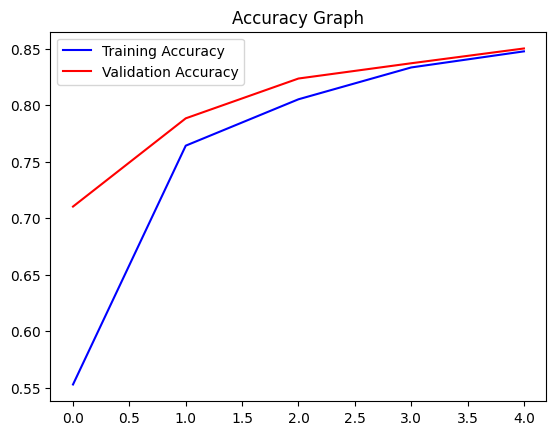

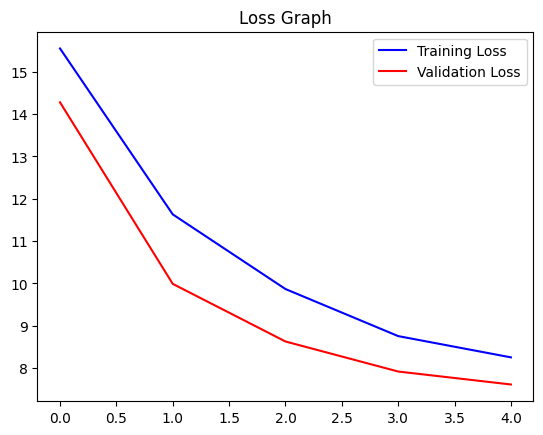

In [ ]:
# plot results for gender
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

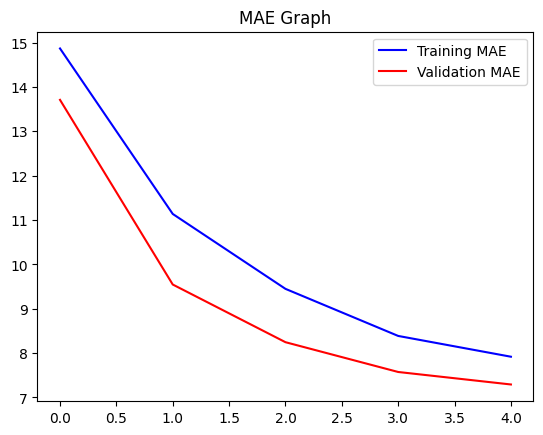

In [ ]:
# plot results for age
loss = history.history['age_out_mae']
val_loss = history.history['val_age_out_mae']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training MAE')
plt.plot(epochs, val_loss, 'r', label='Validation MAE')
plt.title('MAE Graph')
plt.legend()
plt.show()

Original Gender: Female Original Age: 65
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
Predicted Gender: Female Predicted Age: 55


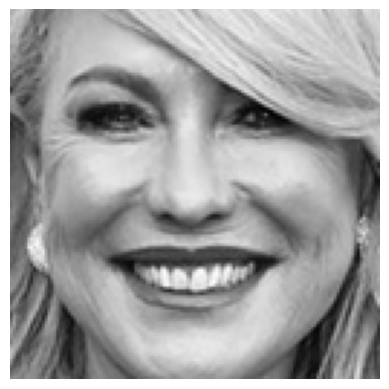

In [ ]:
image_index = 100
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

Original Gender: Female Original Age: 75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Gender: Female Predicted Age: 34


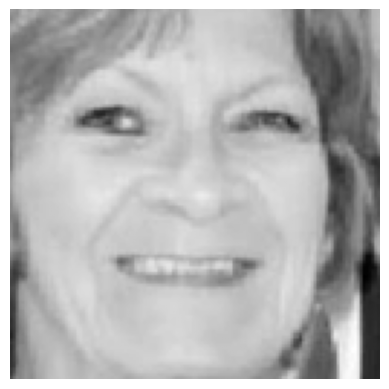

In [ ]:
image_index = 3000
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

Original Gender: Female Original Age: 37
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted Gender: Female Predicted Age: 23


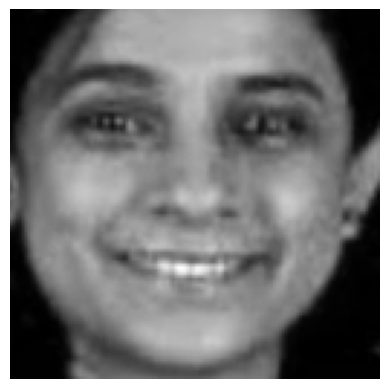

In [ ]:
image_index = 10000
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');

In [ ]:
model.save("age_gender_model.h5")